# Challenge 2: Anomalous Sound Detection (Baseline)

This notebook implements an honest, rigorous baseline for unsupervised anomaly detection on the MIMII Slide Rail dataset, following professional ML research methodologies.

## Methodology
1. **Unsupervised Setup:** We train exclusively on normal machine sounds. Anomalies are never seen during training.
2. **Rigorous Splitting:** We split the provided training data into a 90% training set and a 10% validation set. The validation set is used to tune hyperparameters (like the anomaly decision threshold) without leaking the test set into our model.
3. **Baseline Model:** A fully-connected Autoencoder operating on Log-Mel Spectrograms. The reconstruction error (MSE) serves as the anomaly score.
4. **Evaluation:** We evaluate on the official test set using Area Under the ROC Curve (AUC).

In [1]:
import os
import glob
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# MPS (Metal Performance Shaders) support for Mac M1/M2/M3
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Data Preprocessing

We convert the raw audio signals into Log-Mel Spectrograms. To provide context, we group multiple consecutive frames together into a single feature vector.

In [2]:
def extract_log_mel_spectrogram(file_path, n_mels=128, n_fft=1024, hop_length=512):
    """
    Extracts Log-Mel Spectrogram from an audio file.
    Returns an array of shape (n_frames, n_mels).
    """
    y, sr = librosa.load(file_path, sr=None)  # Native sample rate (16 kHz)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec.T  # Transpose to (time, features)

def create_frame_windows(spectrogram, context_frames=5):
    """
    Concatenates adjacent frames to provide temporal context to the Autoencoder.
    """
    n_frames = spectrogram.shape[0]
    windows = []
    # We pad the beginning and end to keep the same number of frames
    pad_len = context_frames // 2
    padded_spec = np.pad(spectrogram, ((pad_len, pad_len), (0, 0)), mode='edge')
    
    for i in range(n_frames):
        window = padded_spec[i:i + context_frames]
        windows.append(window.flatten())
    return np.array(windows)

## 2. Dataset Loading and Leakage-Free Splitting

We iterate through the dataset. The official training set contains ONLY normal sounds. We hold out 10% for internal validation. The test set contains both normal and anomalous sounds, and we extract true labels for evaluation.

In [3]:
base_dir = "dataset/dev_data/dev_data/slider"

# Hyperparameters
N_MELS = 128
CONTEXT_FRAMES = 5
FEATURE_DIM = N_MELS * CONTEXT_FRAMES

def load_dataset(mode='train'):
    path = os.path.join(base_dir, mode, "*.wav")
    files = glob.glob(path)
    
    X = []
    y = [] # 0 for normal, 1 for anomaly
    machine_ids = []
    
    print(f"Loading {mode} files...")
    for f in tqdm(files):
        basename = os.path.basename(f)
        parts = basename.replace('.wav', '').split('_')
        condition = parts[0]
        m_id = parts[2]
        
        label = 0 if condition == "normal" else 1
        
        # Extract features
        spec = extract_log_mel_spectrogram(f, n_mels=N_MELS)
        windows = create_frame_windows(spec, context_frames=CONTEXT_FRAMES)
        
        X.append(windows)
        y.append(label)
        machine_ids.append(m_id)
        
    return X, np.array(y), np.array(machine_ids)

# Load full train dataset
X_train_full, y_train_full, ids_train = load_dataset('train')

# Rigorous Split: 90% Train, 10% Validation (grouped by file)
# Note: X_train_full is a list of arrays (one array per audio file).
idx = np.arange(len(X_train_full))
train_idx, val_idx = train_test_split(idx, test_size=0.1, random_state=42)

# Flatten the windows for Autoencoder training
X_train = np.vstack([X_train_full[i] for i in train_idx])
X_val = np.vstack([X_train_full[i] for i in val_idx])

print(f"Train feature shape: {X_train.shape}")
print(f"Val feature shape: {X_val.shape}")

# Load Test Dataset
X_test_files, y_test, ids_test = load_dataset('test')

Loading train files...


  0%|          | 0/2370 [00:00<?, ?it/s]

Train feature shape: (667629, 640)
Val feature shape: (74181, 640)
Loading test files...


  0%|          | 0/1101 [00:00<?, ?it/s]

## 3. Autoencoder Baseline Model

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(True),
            nn.Linear(64, 32),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(True),
            nn.Linear(128, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

model = Autoencoder(FEATURE_DIM).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

## 4. Training Loop

In [5]:
BATCH_SIZE = 512
EPOCHS = 15

train_tensor = torch.tensor(X_train, dtype=torch.float32)
val_tensor = torch.tensor(X_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor, val_tensor), batch_size=BATCH_SIZE, shuffle=False)

train_losses = []
val_losses = []

print("Training Baseline Autoencoder...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        recon = model(batch_x)
        loss = criterion(recon, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            recon = model(batch_x)
            loss = criterion(recon, batch_x)
            val_loss += loss.item()
            
    avg_train = epoch_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

Training Baseline Autoencoder...
Epoch 01/15 | Train Loss: 103.6854 | Val Loss: 15.1476
Epoch 02/15 | Train Loss: 13.6644 | Val Loss: 13.1241
Epoch 03/15 | Train Loss: 11.8727 | Val Loss: 11.6867
Epoch 04/15 | Train Loss: 11.0108 | Val Loss: 11.2752
Epoch 05/15 | Train Loss: 10.4577 | Val Loss: 10.7586
Epoch 06/15 | Train Loss: 10.0376 | Val Loss: 10.2047
Epoch 07/15 | Train Loss: 9.7820 | Val Loss: 10.1303
Epoch 08/15 | Train Loss: 9.6181 | Val Loss: 10.0169
Epoch 09/15 | Train Loss: 9.4944 | Val Loss: 9.8718
Epoch 10/15 | Train Loss: 9.3949 | Val Loss: 9.6687
Epoch 11/15 | Train Loss: 9.3144 | Val Loss: 9.4137
Epoch 12/15 | Train Loss: 9.2594 | Val Loss: 9.4965
Epoch 13/15 | Train Loss: 9.2104 | Val Loss: 9.4886
Epoch 14/15 | Train Loss: 9.1735 | Val Loss: 9.5438
Epoch 15/15 | Train Loss: 9.1364 | Val Loss: 9.5044


## 5. Rigorous Evaluation (AUC)
For each audio file in the test set, we compute the reconstruction MSE for every frame. The anomaly score for the entire file is the **mean reconstruction error** across all its frames.

Scoring Test Set:   0%|          | 0/1101 [00:00<?, ?it/s]


--- Evaluation Results (AUC) ---
Machine ID 00: AUC = 0.9592
Machine ID 02: AUC = 0.7722
Machine ID 04: AUC = 0.9102

Overall AUC: 0.8705


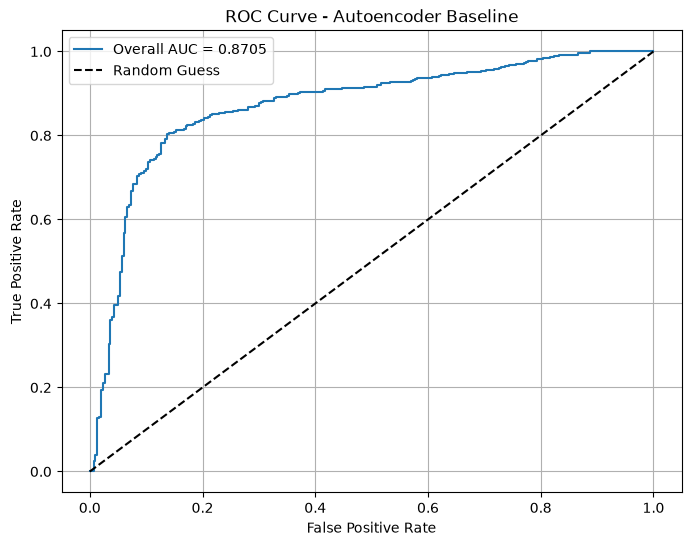

In [6]:
def calculate_anomaly_score(file_features, model):
    model.eval()
    tensor_features = torch.tensor(file_features, dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = model(tensor_features)
        # Calculate MSE per frame, then mean across all frames for this file
        mse_per_frame = torch.mean((tensor_features - recon) ** 2, dim=1)
        file_score = torch.mean(mse_per_frame).item()
    return file_score

# Score all test files
test_scores = []
for file_feats in tqdm(X_test_files, desc="Scoring Test Set"):
    score = calculate_anomaly_score(file_feats, model)
    test_scores.append(score)

test_scores = np.array(test_scores)

# Calculate AUC per Machine ID
print("\n--- Evaluation Results (AUC) ---")
for m_id in np.unique(ids_test):
    idx = (ids_test == m_id)
    y_true = y_test[idx]
    y_scores = test_scores[idx]
    
    auc = roc_auc_score(y_true, y_scores)
    print(f"Machine ID {m_id}: AUC = {auc:.4f}")

# Overall AUC
overall_auc = roc_auc_score(y_test, test_scores)
print(f"\nOverall AUC: {overall_auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Overall AUC = {overall_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Autoencoder Baseline')
plt.legend()
plt.grid(True)
plt.show()